# GravLens-Net — Phase 2: Realistic Data Pipeline

**Goal:** move the Phase 1 baseline closer to what real survey data actually
looks like, and build the loading/preprocessing pipeline that real Bologna
Challenge / KiDS cutouts will plug into.

**Important scope note:** the real Bologna Strong Gravitational Lens Finding
Challenge data lives on `metcalf1.difa.unibo.it` (several GB per band) and
isn't reachable from the environment this notebook was built in. This phase
therefore does two things instead of skipping straight to real data:

1. Upgrades the synthetic simulator to match the **real challenge's documented
   format** — 101×101 px stamps, PSF blur, masked artifact regions (pixel
   value 100), and fainter/subtler arcs than Phase 1 used.
2. Builds the **preprocessing pipeline** (masking, standardization, stratified
   split, FITS loader) against that realistic format, so it's a drop-in fit
   once real data is downloaded locally — see
   `scripts/download_bologna_challenge.py` for that step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)


## 1. Simulator v2 — matching the real challenge format

Changes from Phase 1:
- **101×101 px** (was 64×64) — matches the real Bologna Ground-Based stamps
- **PSF blur** (Gaussian convolution) applied after rendering, like
  seeing-limited ground-based imaging
- **Masked artifact patches** at pixel value 100 — the real challenge data
  documents exactly this convention for bad pixels / CCD gaps / satellite
  trails
- **Fainter arcs** (lower source amplitude) — Phase 1's arcs were bold enough
  that the baseline nearly solved the task outright, which isn't realistic


In [2]:
IMG_SIZE = 101
HALF = IMG_SIZE / 2.0
MASK_VALUE = 100.0

def _grid():
    x = np.linspace(-HALF, HALF, IMG_SIZE)
    y = np.linspace(-HALF, HALF, IMG_SIZE)
    return np.meshgrid(x, y)

def sersic(x, y, amplitude, r_eff, n=2.0, x0=0.0, y0=0.0, ellip=0.0, theta=0.0):
    dx, dy = x - x0, y - y0
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    xr = dx * cos_t + dy * sin_t
    yr = -dx * sin_t + dy * cos_t
    q = 1.0 - ellip
    r = np.sqrt(xr ** 2 + (yr / max(q, 1e-3)) ** 2)
    bn = 1.9992 * n - 0.3271
    return amplitude * np.exp(-bn * ((r / r_eff) ** (1.0 / n) - 1.0))

def gaussian_blob(x, y, amplitude, sigma, x0=0.0, y0=0.0):
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return amplitude * np.exp(-r2 / (2 * sigma ** 2))

def sis_deflect(x, y, theta_E, x0=0.0, y0=0.0):
    dx, dy = x - x0, y - y0
    r = np.sqrt(dx ** 2 + dy ** 2)
    r_safe = np.maximum(r, 1e-6)
    alpha_x = theta_E * dx / r_safe
    alpha_y = theta_E * dy / r_safe
    return dx - alpha_x, dy - alpha_y

def apply_psf(img, seeing_sigma):
    return gaussian_filter(img, sigma=seeing_sigma)

def add_artifact_mask(img, rng, p_mask=0.15):
    if rng.random() >= p_mask:
        return img
    h, w = rng.integers(4, 14), rng.integers(4, 14)
    top, left = rng.integers(0, IMG_SIZE - h), rng.integers(0, IMG_SIZE - w)
    img = img.copy()
    img[top:top + h, left:left + w] = MASK_VALUE
    return img

def add_noise(img, sky_level=0.02, read_noise=0.015, rng=None):
    rng = rng or np.random.default_rng()
    img = np.clip(img, 0, None)
    shot = rng.normal(0, np.sqrt(img + sky_level) * 0.05, img.shape)
    read = rng.normal(0, read_noise, img.shape)
    return img + sky_level + shot + read


In [3]:
def make_lens_image(rng, seeing_sigma=1.3):
    x, y = _grid()
    img = sersic(x, y, rng.uniform(0.6, 1.0), rng.uniform(5.0, 11.0), rng.uniform(1.5, 4.0),
                 0, 0, rng.uniform(0.0, 0.3), rng.uniform(0, np.pi))
    theta_E = rng.uniform(7.0, 14.0)
    src_offset = rng.uniform(0.0, 0.5) * theta_E
    src_angle = rng.uniform(0, 2 * np.pi)
    src_x0, src_y0 = src_offset * np.cos(src_angle), src_offset * np.sin(src_angle)
    src_amp = rng.uniform(0.15, 0.45)   # fainter than Phase 1
    src_sigma = rng.uniform(1.2, 2.2)
    beta_x, beta_y = sis_deflect(x, y, theta_E)
    lensed = gaussian_blob(beta_x, beta_y, src_amp, src_sigma, src_x0, src_y0)
    img = apply_psf(img + lensed, seeing_sigma)
    img = add_noise(img, rng=rng)
    return add_artifact_mask(img, rng)

def make_isolated_galaxy(rng, seeing_sigma=1.3):
    x, y = _grid()
    img = sersic(x, y, rng.uniform(0.6, 1.0), rng.uniform(5.0, 12.0), rng.uniform(0.8, 4.0),
                 0, 0, rng.uniform(0.0, 0.5), rng.uniform(0, np.pi))
    img = apply_psf(img, seeing_sigma)
    img = add_noise(img, rng=rng)
    return add_artifact_mask(img, rng)

def make_merger_pair(rng, seeing_sigma=1.3):
    x, y = _grid()
    img = sersic(x, y, rng.uniform(0.6, 1.0), rng.uniform(5, 9), rng.uniform(1, 3),
                 0, 0, rng.uniform(0, 0.4), rng.uniform(0, np.pi))
    sep = rng.uniform(8, 22)
    ang = rng.uniform(0, 2 * np.pi)
    x0, y0 = sep * np.cos(ang), sep * np.sin(ang)
    img = img + sersic(x, y, rng.uniform(0.3, 0.7), rng.uniform(3, 7), rng.uniform(1, 3),
                        x0, y0, rng.uniform(0, 0.4), rng.uniform(0, np.pi))
    img = apply_psf(img, seeing_sigma)
    img = add_noise(img, rng=rng)
    return add_artifact_mask(img, rng)

def make_spiral(rng, seeing_sigma=1.3):
    x, y = _grid()
    r = np.sqrt(x ** 2 + y ** 2)
    phi = np.arctan2(y, x)
    pitch = rng.uniform(0.2, 0.4)
    arm_pattern = 0.5 + 0.5 * np.cos(2 * (phi - r * pitch))
    disk = sersic(x, y, rng.uniform(0.5, 0.9), rng.uniform(8, 13), 1.0, 0, 0)
    img = apply_psf(disk * (0.5 + 0.5 * arm_pattern), seeing_sigma)
    img = add_noise(img, rng=rng)
    return add_artifact_mask(img, rng)

def generate_dataset(n_neg=2500, n_pos=50, seed=42):
    rng = np.random.default_rng(seed)
    images, labels, subtypes = [], [], []
    neg_makers = [make_isolated_galaxy, make_merger_pair, make_spiral]
    neg_weights = [0.6, 0.2, 0.2]
    for _ in range(n_neg):
        maker = rng.choice(neg_makers, p=neg_weights)
        images.append(maker(rng)); labels.append(0); subtypes.append(maker.__name__)
    for _ in range(n_pos):
        images.append(make_lens_image(rng)); labels.append(1); subtypes.append("lens")
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    subtypes = np.array(subtypes)
    perm = rng.permutation(len(images))
    return images[perm], labels[perm], subtypes[perm]


## 2. Visual check — subtler arcs, visible masking

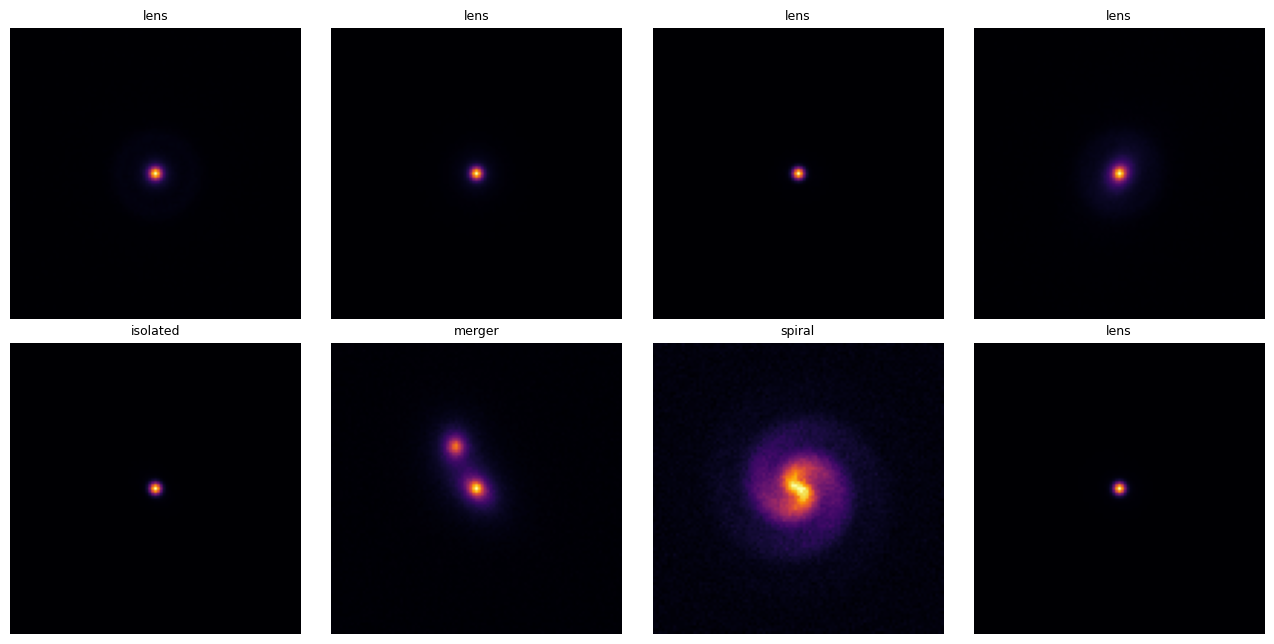

In [4]:
rng = np.random.default_rng(11)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
titles = ["lens", "lens", "lens", "lens",
          "isolated", "merger", "spiral", "lens"]
imgs = [make_lens_image(rng) for _ in range(4)] + \
       [make_isolated_galaxy(rng), make_merger_pair(rng), make_spiral(rng), make_lens_image(rng)]
for ax, img, t in zip(axes.flat, imgs, titles):
    ax.imshow(img, cmap="inferno")
    ax.set_title(t, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Preprocessing pipeline

Built against the real format's documented quirks — most importantly, masked
pixels are a fixed sentinel value (100), and if left untreated a model can
learn "flat grey patch present" as a spurious shortcut instead of looking at
the actual source. `mask_to_nan_then_fill` replaces masked pixels with the
per-image local median before standardization.


In [5]:
def mask_to_nan_then_fill(images, fill="local_median"):
    images = images.astype(np.float32).copy()
    mask = np.isclose(images, MASK_VALUE)
    if not mask.any():
        return images
    for i in range(images.shape[0]):
        if mask[i].any():
            med = np.median(images[i][~mask[i]]) if (~mask[i]).any() else 0.0
            images[i][mask[i]] = med
    return images

def standardize(images):
    mean = images.mean(axis=(1, 2), keepdims=True)
    std = images.std(axis=(1, 2), keepdims=True) + 1e-6
    return (images - mean) / std

def stratified_split(images, labels, val_frac=0.15, test_frac=0.15, seed=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, labels, test_size=val_frac + test_frac, stratify=labels, random_state=seed)
    rel_test = test_frac / (val_frac + test_frac)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=rel_test, stratify=y_temp, random_state=seed)
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


## 4. Run the pipeline end-to-end on the v2 simulator (stand-in for real data)

In [6]:
images, labels, subtypes = generate_dataset(n_neg=2500, n_pos=50, seed=SEED)
print("raw:", images.shape, "| masked fraction of images:",
      round(np.mean([np.isclose(im, MASK_VALUE).any() for im in images]), 3))

images = mask_to_nan_then_fill(images)
images = standardize(images)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_split(images, labels)
print(f"train={len(y_train)} (pos={y_train.sum()})  val={len(y_val)} (pos={y_val.sum()})  test={len(y_test)} (pos={y_test.sum()})")


raw: (2550, 101, 101) | masked fraction of images: 0.146


train=1785 (pos=35)  val=382 (pos=7)  test=383 (pos=8)


## 5. Status & Next Steps

**What's done in Phase 2:**
- Simulator upgraded to 101×101, PSF-blurred, masked-artifact, fainter-arc
  format matching the real challenge's documented spec
- Full preprocessing pipeline (masking, standardization, stratified split)
  built and tested against that format
- `scripts/download_bologna_challenge.py` — ready for you to run locally to
  pull the real training set (this environment can't reach
  `metcalf1.difa.unibo.it`, so this step has to happen on your machine)
- `preprocessing.load_from_fits_dir()` — ready to convert real downloaded
  FITS + catalog into the same `(images, labels)` format used above, so
  Phase 3 model training code doesn't need to change when real data comes in

**What's genuinely still open:**
- Whether the real download links on the challenge page are even still live
  (the challenge ended in 2020) — the post-challenge "Data Set Release" truth
  tables on the same page are a smaller, more likely-to-work fallback
  ("Ground set 1..5 and Truth table")
- Real arcs will likely be harder than even this fainter simulation — that
  synthetic-to-real gap won't be measurable until real data is actually
  loaded through this pipeline

**Phase 3 (once real or better-simulated data is in hand):** retrain the
baseline CNN on the harder v2-format data, quantify how much the fainter
arcs + masking degrade Phase 1's numbers, then iterate architecture/imbalance
handling from there — same structure as ExoTransit-Net's Phase 3.
